In [1]:
import pandas as pd
import re
import numpy as np
from io import StringIO   # <-- use isto
import matplotlib.pyplot as plt

# Tratamento de Dados

In [3]:
arquivo = "hs/vib_mode.txt"

with open(arquivo, "r") as f:
    linhas = f.readlines()

# --------------------
# 1) Parte inicial (159 linhas)
# --------------------

linhas_159 = linhas[:159]

header = re.split(r"\s+", linhas[0].strip())
header = [h for h in header if h != ""]

df = pd.read_csv(
    StringIO("".join(linhas_159)),
    delim_whitespace=True,
    names=header,
    skiprows=1
)

# --------------------
# 2) Blocos seguintes
# --------------------

blocos = []
i = 159

num_regex = r"^\s*\d+(\s+\d+)*\s*$"

while i < len(linhas):

    # Linha com números das colunas
    col_header_line = linhas[i].strip()
    novas_cols = re.split(r"\s+", col_header_line)
    novas_cols = [c for c in novas_cols if c != ""]
    i += 1

    bloco_linhas = []

    # Acumular linhas do bloco
    while i < len(linhas) and not re.match(num_regex, linhas[i]):
        bloco_linhas.append(linhas[i])
        i += 1

    # Se não houver linhas, pula
    if len(bloco_linhas) == 0:
        continue

    # ----------------------------
    # Detectar número real de colunas no bloco
    # ----------------------------
    primeira_linha = bloco_linhas[0].strip()
    ncols = len(re.split(r"\s+", primeira_linha))

    # criar nomes para todas as colunas
    # primeira é índice, outras são novas_cols (até onde existirem)
    nomes = ["idx"] + novas_cols + [f"extra_{k}" for k in range(len(novas_cols)+1, ncols)]

    df_bloco = pd.read_csv(
        StringIO("".join(bloco_linhas)),
        delim_whitespace=True,
        names=nomes
    )

    df_bloco = df_bloco.drop(columns=["idx"])
    blocos.append(df_bloco)

# --------------------
# 3) Concatenar
# --------------------

for b in blocos:
    df = pd.concat([df, b], axis=1)

C:\Users\55219\AppData\Local\Temp\ipykernel_16544\891586951.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_16544\891586951.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_16544\891586951.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_16544\891586951.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_16544\891586951.py:60:

In [5]:
def renomear_index_por_atom(df, lista_atomica):
    """
    df: DataFrame final já criado (159 linhas)
    lista_atomica: lista de strings com linhas contendo símbolo, massa e coordenadas
    """
    # Extrair apenas o símbolo atômico de cada linha
    simbolos = [linha.split()[0] for linha in lista_atomica]

    novo_index = []
    contadores = {}  # exemplo: {"C":1, "H":1, "O":1}

    for simbolo in simbolos:
        if simbolo not in contadores:
            contadores[simbolo] = 1

        nome = f"{simbolo}{contadores[simbolo]}"

        # Cada átomo corresponde a 3 linhas do DataFrame
        novo_index.extend([nome, nome, nome])

        contadores[simbolo] += 1

    # Aplicar ao DataFrame
    df.index = novo_index
    return df

In [7]:
lista_atomica = [
    "C     12.01100     -5.520264845720    -1.115707479413     0.897605357711",
    "C     12.01100      5.520452518574    -1.115723577676    -0.897303843581",
    "C     12.01100     -4.717428065189    -2.832744402920    -1.052293345657",
    "C     12.01100      4.717889260456    -2.832871384362     1.052539744557",
    "C     12.01100     -6.606891583710    -4.394353536396    -2.145371212533",
    "C     12.01100      6.607390344081    -4.394770037602     2.145057663476",
    "H      1.00800     -6.034676638152    -5.702671048362    -3.610513207819",
    "H      1.00800      6.035355292474    -5.703243699406     3.610128208214",
    "C     12.01100     -9.066360064720    -4.254075940367    -1.367474199670",
    "C     12.01100      9.066728222324    -4.254628795559     1.366661179528",
    "H      1.00800    -10.511265866955    -5.441454535473    -2.193507432040",
    "H      1.00800     10.511683451023    -5.442288278089     2.192214608511",
    "C     12.01100     -9.770578178244    -2.550150813499     0.537008619724",
    "C     12.01100      9.770715542304    -2.550563288206    -0.537744580628",
    "C     12.01100     -8.020310169408    -0.994075397066     1.671451991949",
    "C     12.01100      8.020340638195    -0.994159763824    -1.671623622263",
    "N     14.00700    -12.378556223629    -2.409089787803     1.327755332438",
    "N     14.00700     12.378519201596    -2.409668247301    -1.329083667815",
    "O     15.99900     -2.416219571234    -2.903288706253    -1.747879105684",
    "O     15.99900      2.416744722791    -2.903297471670     1.748496268000",
    "O     15.99900    -13.888079551984    -3.808782207744     0.304531482779",
    "O     15.99900     13.888086558489    -3.809858819272    -0.306655649681",
    "O     15.99900    -12.928247729108    -0.893379703175     2.972383430461",
    "O     15.99900     12.927953998234    -0.893763939771    -2.973651371779",
    "N     14.00700     -3.564693824940     0.330596326795     1.821477061978",
    "N     14.00700      3.564735878326     0.330650146953    -1.820781402117",
    "H      1.00800     -8.649557134583     0.282766099379     3.140249066382",
    "H      1.00800      8.649412269810     0.282821974285    -3.140385031032",
    "C     12.01100     -3.655291153411     2.031063880783     3.536851991090",
    "C     12.01100      3.655056986834     2.030838091497    -3.536441828175",
    "H      1.00800     -5.377071945919     2.549964151628     4.541848489297",
    "C     12.01100     -1.310384408628     3.291486455883     4.191970491532",
    "C     12.01100      1.310046939264     3.291108840358    -4.191443794614",
    "H      1.00800      5.376641385352     2.549464552762    -4.541919460723",
    "N     14.00700      0.741387328905     2.577206192449     2.876254138590",
    "C     12.01100     -1.181804924987     5.094014086095     6.099820375343",
    "C     12.01100      1.181227147302     5.093277810341    -6.099625154786",
    "N     14.00700     -0.741599888669     2.576856952799    -2.875508194828",
    "C     12.01100      2.955085757498     3.593295877611     3.458276208785",
    "H      1.00800     -2.881312278661     5.626521498741     7.109401298976",
    "C     12.01100      1.133402062841     6.155165171408     6.683444521954",
    "H      1.00800      2.880649251831     5.625718623776    -7.109394845466",
    "C     12.01100     -1.134093225637     6.154099585433    -6.683384268274",
    "C     12.01100     -2.955402360777     3.592657946625    -3.457669967266",
    "H      1.00800      4.565823766006     2.942241245285     2.371070162337",
    "C     12.01100      3.249950073085     5.383762691732     5.348576630598",
    "H      1.00800      1.287843102082     7.556621529536     8.167726618197",
    "C     12.01100     -3.250503942796     5.382767012137    -5.348272220948",
    "H      1.00800     -1.288716667155     7.555250245205    -8.167932773460",
    "H      1.00800     -4.566072050899     2.941572288416    -2.370400223201",
    "H      1.00800      5.104212185344     6.145690387923     5.751937690401",
    "H      1.00800     -5.104864181243     6.144415297879    -5.751727712650",
    "Fe    55.85000      0.000239285754    -0.441112578978     0.000655619575"
]

In [9]:
df = renomear_index_por_atom(df, lista_atomica)

In [11]:
df

,0,1,2,3,4,5,6,7,8,9,...,149,150,151,152,153,154,155,156,157,158
C1,0.0,0.0,0.0,0.0,0.0,0.0,-0.011739,-0.021430,-0.004655,0.015593,...,2.777948e-05,-1.058841e-05,-2.557596e-04,-2.176797e-04,9.971602e-05,-2.953628e-03,-0.000026,0.000037,1.164970e-06,7.820120e-05
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.002892,0.015600,-0.028117,0.000218,...,5.815374e-06,-4.905272e-06,3.195445e-05,3.445086e-05,-1.184876e-05,2.558133e-04,-0.000010,0.000040,-5.120854e-06,-1.994626e-04
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.014217,-0.027116,-0.001637,0.022267,...,9.615572e-07,1.402071e-06,1.102211e-04,1.027149e-04,-4.131598e-05,1.027926e-03,0.000008,0.000037,-6.137622e-06,-2.197849e-04
C2,0.0,0.0,0.0,0.0,0.0,0.0,0.012088,-0.021113,0.004643,0.015332,...,-2.699664e-05,8.580539e-06,-2.319022e-04,2.432777e-04,-2.953281e-03,-1.141929e-04,-0.000043,0.000015,7.713525e-05,-3.470026e-06
C2,0.0,0.0,0.0,0.0,0.0,0.0,0.003238,-0.015440,-0.028110,-0.001830,...,7.647770e-06,3.984111e-07,-2.785643e-05,3.728247e-05,-2.561236e-04,-6.637755e-06,0.000042,0.000002,1.994522e-04,-6.749640e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H16,0.0,0.0,0.0,0.0,0.0,0.0,-0.171571,0.077697,0.071083,-0.174931,...,-5.947492e-02,1.194187e-01,-8.989367e-03,6.451043e-04,1.276854e-03,-3.049811e-04,0.323855,0.048016,1.206586e-04,4.779802e-04
H16,0.0,0.0,0.0,0.0,0.0,0.0,-0.022917,-0.085092,0.144110,-0.039325,...,3.216589e-02,-6.464101e-02,4.858906e-03,-3.449798e-04,-6.909627e-04,1.495249e-04,-0.171859,-0.025480,-6.201723e-05,-2.393312e-04
Fe1,0.0,0.0,0.0,0.0,0.0,0.0,0.000211,-0.032254,-0.000040,0.033928,...,-1.075789e-06,-3.309730e-06,-2.604103e-05,1.390564e-06,-9.674483e-06,-1.042146e-05,0.000005,-0.000003,2.174759e-06,2.020556e-06
Fe1,0.0,0.0,0.0,0.0,0.0,0.0,-0.078461,-0.000634,-0.074633,-0.000587,...,7.751774e-06,-2.565032e-06,-7.599853e-07,-1.483712e-05,-2.151795e-06,1.994638e-06,0.000018,0.000024,-3.023640e-07,3.084705e-07


# Plot

In [13]:
df

,0,1,2,3,4,5,6,7,8,9,...,149,150,151,152,153,154,155,156,157,158
C1,0.0,0.0,0.0,0.0,0.0,0.0,-0.011739,-0.021430,-0.004655,0.015593,...,2.777948e-05,-1.058841e-05,-2.557596e-04,-2.176797e-04,9.971602e-05,-2.953628e-03,-0.000026,0.000037,1.164970e-06,7.820120e-05
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.002892,0.015600,-0.028117,0.000218,...,5.815374e-06,-4.905272e-06,3.195445e-05,3.445086e-05,-1.184876e-05,2.558133e-04,-0.000010,0.000040,-5.120854e-06,-1.994626e-04
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.014217,-0.027116,-0.001637,0.022267,...,9.615572e-07,1.402071e-06,1.102211e-04,1.027149e-04,-4.131598e-05,1.027926e-03,0.000008,0.000037,-6.137622e-06,-2.197849e-04
C2,0.0,0.0,0.0,0.0,0.0,0.0,0.012088,-0.021113,0.004643,0.015332,...,-2.699664e-05,8.580539e-06,-2.319022e-04,2.432777e-04,-2.953281e-03,-1.141929e-04,-0.000043,0.000015,7.713525e-05,-3.470026e-06
C2,0.0,0.0,0.0,0.0,0.0,0.0,0.003238,-0.015440,-0.028110,-0.001830,...,7.647770e-06,3.984111e-07,-2.785643e-05,3.728247e-05,-2.561236e-04,-6.637755e-06,0.000042,0.000002,1.994522e-04,-6.749640e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H16,0.0,0.0,0.0,0.0,0.0,0.0,-0.171571,0.077697,0.071083,-0.174931,...,-5.947492e-02,1.194187e-01,-8.989367e-03,6.451043e-04,1.276854e-03,-3.049811e-04,0.323855,0.048016,1.206586e-04,4.779802e-04
H16,0.0,0.0,0.0,0.0,0.0,0.0,-0.022917,-0.085092,0.144110,-0.039325,...,3.216589e-02,-6.464101e-02,4.858906e-03,-3.449798e-04,-6.909627e-04,1.495249e-04,-0.171859,-0.025480,-6.201723e-05,-2.393312e-04
Fe1,0.0,0.0,0.0,0.0,0.0,0.0,0.000211,-0.032254,-0.000040,0.033928,...,-1.075789e-06,-3.309730e-06,-2.604103e-05,1.390564e-06,-9.674483e-06,-1.042146e-05,0.000005,-0.000003,2.174759e-06,2.020556e-06
Fe1,0.0,0.0,0.0,0.0,0.0,0.0,-0.078461,-0.000634,-0.074633,-0.000587,...,7.751774e-06,-2.565032e-06,-7.599853e-07,-1.483712e-05,-2.151795e-06,1.994638e-06,0.000018,0.000024,-3.023640e-07,3.084705e-07


In [15]:
atomos = [('O1',15.99900),('O2',15.99900),('N3',14.00700),('N4',14.00700),('N5',14.00700),('N6',14.00700),('Fe1',55.85000)]
#atomos = [('O1',1),('O2',1),('N3',1),('N4',1),('N5',1),('N6',1),('Fe1',1)]
atomos_tot = [
("C1", 12.01100),
("C2", 12.01100),
("C3", 12.01100),
("C4", 12.01100),
("C5", 12.01100),
("C6", 12.01100),
("H1", 1.00800),
("H2", 1.00800),
("C7", 12.01100),
("C8", 12.01100),
("H3", 1.00800),
("H4", 1.00800),
("C9", 12.01100),
("C10", 12.01100),
("C11", 12.01100),
("C12", 12.01100),
("N1", 14.00700),
("N2", 14.00700),
("O1", 15.99900),
("O2", 15.99900),
("O3", 15.99900),
("O4", 15.99900),
("O5", 15.99900),
("O6", 15.99900),
("N3", 14.00700),
("N4", 14.00700),
("H5", 1.00800),
("H6", 1.00800),
("C13", 12.01100),
("C14", 12.01100),
("H7", 1.00800),
("C15", 12.01100),
("C16", 12.01100),
("H8", 1.00800),
("N5", 14.00700),
("C17", 12.01100),
("C18", 12.01100),
("N6", 14.00700),
("C19", 12.01100),
("H9", 1.00800),
("C20", 12.01100),
("H10", 1.00800),
("C21", 12.01100),
("C22", 12.01100),
("H11", 1.00800),
("C23", 12.01100),
("H12", 1.00800),
("C24", 12.01100),
("H13", 1.00800),
("H14", 1.00800),
("H15", 1.00800),
("H16", 1.00800),
("Fe1", 55.85000)
]


col = np.arange(0,159)

contr_atom = []
contr_atom_total = []

for j in col:
    soma_modo = 0.0
    soma_modo_total = 0
    for at in atomos:
        val = at[1]*((df.loc[str(at[0])]**2)[str(j)]).sum()
        soma_modo += val
        #print(at[0],at[1],str(j))
    for at in atomos_tot:
        val_tot = at[1]*((df.loc[str(at[0])]**2)[str(j)]).sum()
        soma_modo_total += val_tot
        #print(at[0],at[1],str(j))
    contr_atom.append(soma_modo)
    contr_atom_total.append(soma_modo_total)

#FALTA MULTIPLICAR O LOOP PELA MASSA ALAN. TERMINAR QDO VOLTAR O BDJ

In [16]:
Oct = np.array(contr_atom[6:])
Tot = np.array(contr_atom_total[6:])

Contr_oct = Oct/Tot

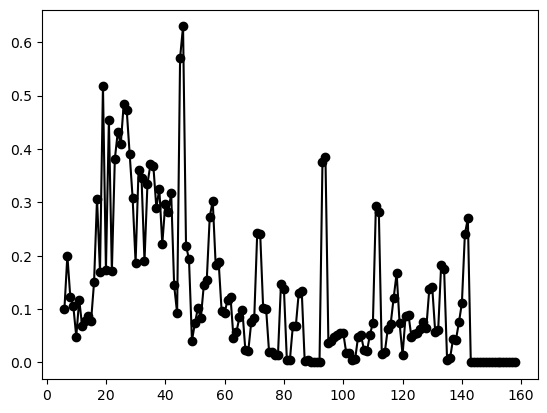

In [17]:
plt.plot(col[6:], Contr_oct,marker='o',color='black')
plt.show()

In [31]:
valores = [
    14.6363826660841259,
    17.7025302166019110,
    27.7276676405888409,
    42.2814962983410325,
    44.7159640630151145,
    56.1591861012805680,
    57.4788522395882779,
    67.3138169435014220,
    71.5448229985533004,
    78.6001590053584067,
    89.7079214949832533,
    101.0013113270149461,
    101.8512433851130794,
    125.6951320106916796,
    132.0341462803493187,
    144.4353905730721408,
    150.0816048532104787,
    158.6094704087291518,
    170.8354340238873590,
    180.1256161038461130,
    204.7691988882948522,
    241.3902504465010850,
    248.5082944391492674,
    263.0101032223427637,
    267.5258800746728980,
    267.9737326120072680,
    272.9089755557190529,
    294.5749530887951551,
    294.9131868625747757,
    313.7388742500849617,
    332.4885430699512199,
    363.5681845191944035,
    368.2366765988276143,
    384.3437658881554171,
    387.5036511155594212,
    424.7843857726216470,
    432.4450304712877937,
    469.9531154242551452,
    472.2164281667477894,
    495.1663050953362131,
    503.7554397952662271,
    518.1479327799355588,
    520.4623415329924683,
    520.4963161669683132,
    522.7697210799245795,
    563.7539640486679673,
    564.1418528580679776,
    567.7896284947015602,
    568.5912273076689871,
    624.5619224141786390,
    631.8202484816461038,
    645.1692827507296215,
    646.6470940568044625,
    658.9277448819937035,
    659.0064243899704479,
    693.1935953641179822,
    694.9077341000180468,
    759.0162487344231295,
    759.3416477790054842,
    766.1717451972057233,
    768.0472479723043762,
    788.9245974848324749,
    789.0952225353265703,
    799.8617593425899486,
    800.5969944946990609,
    837.9230957689824209,
    839.7362332664058613,
    856.0860157910476573,
    856.4445823022042532,
    867.2412951060115347,
    867.5330981992927946,
    904.8501413132449898,
    905.1307518250052908,
    911.9812516483766558,
    915.3117273077996288,
    930.4279990969258733,
    930.4416311462200611,
    952.0147592058744976,
    952.3403217296746561,
    984.2915926665509687,
    987.2765287218052208,
    994.1439545278424248,
    994.6582292824118667,
    1000.5627749386893584,
    1000.5805715146898365,
    1016.0381972203441592,
    1016.0858262499453986,
    1028.8738514867072809,
    1031.8675420679494437,
    1083.0431321109699638,
    1083.2682635500675588,
    1110.1545408355984819,
    1112.1272559126168744,
    1136.1228057479929703,
    1136.4625185107840935,
    1148.8160718081323921,
    1149.4300432126144642,
    1176.1880995238661853,
    1176.8706827589264776,
    1202.3309888638955272,
    1205.3472601066664538,
    1253.1768369486426309,
    1255.3953845964508673,
    1270.7476109134975104,
    1275.6654742482253369,
    1331.1917467088560443,
    1335.0852833938258755,
    1338.1248436710441183,
    1338.2875556404355848,
    1359.7405590315929658,
    1362.6309530278017519,
    1396.0280963740885909,
    1404.4510195451632626,
    1404.6187554097039083,
    1407.6106601878416313,
    1416.5130279103343582,
    1417.0396593492473585,
    1481.2100327315160939,
    1481.6961673094072012,
    1493.2706188816407575,
    1493.3371266899325747,
    1511.4597537779986851,
    1514.9451069732506312,
    1538.0856720502786175,
    1550.2928969248030171,
    1584.5870422989519284,
    1585.5735447958415989,
    1619.5283883871497892,
    1621.1080130720392845,
    1646.4034160156527378,
    1648.0132224704204873,
    1660.3536045584996828,
    1661.5343664535218977,
    1666.8009224481236288,
    1668.2109732925678145,
    1682.0310965981223035,
    1682.5220059425873842,
    3130.0717454980454022,
    3130.1121529289539467,
    3197.5615771035249963,
    3197.6409907739357550,
    3204.3294284144549238,
    3204.3733851859806236,
    3217.1907856229313438,
    3217.2083971840561389,
    3217.4604417434356947,
    3217.4735804482388630,
    3226.0778490712946223,
    3226.1052269928263740,
    3231.0308892954412840,
    3231.0746718400259851,
    3236.9050723647033010,
    3236.9232101069383134
]

In [33]:
len(valores)

153

In [27]:
Contr_oct_df = pd.read_csv("Oct_Contri.csv")

In [35]:
Contr_oct_df['modos'] = valores

In [37]:
Contr_oct_df

,index,valor,array,modos
0,6,14.636383,0.099285,14.636383
1,7,17.702530,0.200384,17.702530
2,8,27.727668,0.121939,27.727668
3,9,42.281496,0.105971,42.281496
4,10,44.715964,0.048656,44.715964
...,...,...,...,...
148,154,3226.105227,0.000005,3226.105227
149,155,3231.030889,0.000005,3231.030889
150,156,3231.074672,0.000005,3231.074672
151,157,3236.905072,0.000002,3236.905072


In [39]:
Contr_oct_df.sort_values(by=['array'],ascending=False)[:15]

,index,valor,array,modos
40,46,503.755440,0.629462,503.755440
39,45,495.166305,0.570897,495.166305
13,19,125.695132,0.518842,125.695132
20,26,204.769199,0.484549,204.769199
21,27,241.390250,0.473349,241.390250
15,21,144.435391,0.454171,144.435391
18,24,170.835434,0.431847,170.835434
19,25,180.125616,0.408547,180.125616
22,28,248.508294,0.389942,248.508294
88,94,1031.867542,0.385721,1031.867542


In [41]:
Contr_oct_df.to_csv('your_file_name.csv', index=False)